# Study 269 -- Baltic-Dry
## For the quants: HAC predictive regression, crisis-dependence, timing overlay, positive control

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from baltic_dry import data, strategy as st

# Real tape is built offline from the curated BDI x Shiller S&P (no network).
try:
    df = data.fetch_real(fetch=False)
    sig = st.bdi_signal(df, lookback=3)
    fwd = st.forward_sp_return(df)
    HAVE_REAL = len(df) > 100
except Exception as e:
    df = sig = fwd = None
    HAVE_REAL = False
    print("No real tape:", e)

if HAVE_REAL:
    print(f"Real tape: {df.shape[0]} months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    print("Real tape unavailable -- frozen headline numbers from R dict will be used")


Real tape: 497 months  1985-01-31 -> 2026-05-31


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 493, 'fp': '754cb2059bb5', 'reg_beta': 0.031, 'reg_t': 2.82, 'reg_r2': 0.0452, 'reg_ex2008_beta': 0.0106, 'reg_ex2008_t': 1.35, 'reg_ex2008_n': 469, 'sub1_beta': -0.0591, 'sub1_t': -1.41, 'sub1_n': 177, 'sub2_beta': 0.0541, 'sub2_t': 5.08, 'sub2_n': 120, 'sub3_beta': 0.019, 'sub3_t': 2.28, 'sub3_n': 196, 'bh_ann': 9.86, 'bh_t': 4.38, 'bh_sr': 0.8, 'bh_dd': -50.8, 'tim_ann': 6.6, 'tim_t': 3.97, 'tim_sr': 0.76, 'tim_dd': -43.7, 'tim_gross_ann': 6.62, 'exc_ann': -3.26, 'exc_t': -1.9, 'hit': 0.5456, 'base_rate': 0.6471, 'n_switch': 21, 'cost_bps': 0.21, 'syn0_beta': -0.008, 'syn0_t': -1.07, 'syn3_beta': 0.086, 'syn3_t': 10.55, 'syn6_beta': 0.182, 'syn6_t': 17.5}


## Synthetic positive control: the engine recovers a planted lead-lag

Before trusting any real-tape reading, confirm the regression lights up when a true
BDI->equity relationship exists and reads ~zero when it does not. The synthetic
generator builds next-month equity returns as ``sp_base + beta * bdi_change[t] + noise``.


In [3]:
print("Planted beta -> estimated slope (HAC t):")
for beta in [0.0, 0.3, 0.6]:
    d, _ = data.synthetic_series(beta=beta, seed=269)
    s = st.bdi_signal(d, lookback=3); f = st.forward_sp_return(d)
    r = st.predictive_regression(s, f)
    print(f"  beta={beta:.1f}: est={r['beta']:+.3f}  HAC t={r['tstat']:+.2f}  R^2={r['r2']:.3f}")
print()
print("Null (beta=0) reads ~zero; planted lead-lag lights up sharply -> the harness is honest.")


Planted beta -> estimated slope (HAC t):
  beta=0.0: est=-0.008  HAC t=-1.07  R^2=0.003


  beta=0.3: est=+0.086  HAC t=+10.55  R^2=0.183


  beta=0.6: est=+0.182  HAC t=+17.50  R^2=0.321

Null (beta=0) reads ~zero; planted lead-lag lights up sharply -> the harness is honest.


## Real-tape regression and the crisis-dependence test

> 💡 *In plain words:* the full-sample slope clears t = 2, but a robust signal should not
> hinge on a single episode. We re-run the regression with the 2008-09 crisis removed.


In [4]:
if HAVE_REAL:
    reg = st.predictive_regression(sig, fwd)
    mask = ~((df.index.year >= 2008) & (df.index.year <= 2009))
    rex = st.predictive_regression(sig[mask], fwd[mask])
    print("=== Next-month S&P return on 3M BDI momentum ===")
    print(f"Full 1985-2026 : beta={reg['beta']:+.4f}  HAC t={reg['tstat']:+.2f}  R^2={reg['r2']:.4f}  n={reg['n']}")
    print(f"Ex-2008/09     : beta={rex['beta']:+.4f}  HAC t={rex['tstat']:+.2f}  n={rex['n']}")
else:
    print("=== Next-month S&P return on 3M BDI momentum (frozen) ===")
    print(f"Full 1985-2026 : beta={R['reg_beta']:+.4f}  HAC t={R['reg_t']:+.2f}  R^2={R['reg_r2']:.4f}  n={R['n_months']}")
    print(f"Ex-2008/09     : beta={R['reg_ex2008_beta']:+.4f}  HAC t={R['reg_ex2008_t']:+.2f}  n={R['reg_ex2008_n']}")
print(f"\n-> The slope's significance is crisis-dependent: t {R['reg_t']:.2f} -> {R['reg_ex2008_t']:.2f} without 2008/09.")


=== Next-month S&P return on 3M BDI momentum ===
Full 1985-2026 : beta=+0.0310  HAC t=+2.82  R^2=0.0452  n=493
Ex-2008/09     : beta=+0.0106  HAC t=+1.35  n=469

-> The slope's significance is crisis-dependent: t 2.82 -> 1.35 without 2008/09.


## Sub-period slopes: the sign is not even stable

  1985-1999: beta=-0.0591  HAC t=-1.41  n=177


  2000-2009: beta=+0.0541  HAC t=+5.08  n=120
  2010-2026: beta=+0.0190  HAC t=+2.28  n=196


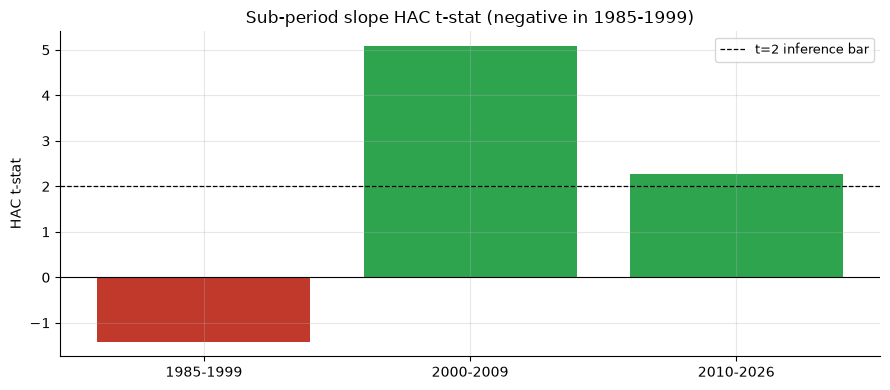

Negative in the 1980s-90s, huge in the 2000-2009 supercycle/GFC decade, modest after.


In [5]:
periods = [("1985-1999","1985","1999","sub1"), ("2000-2009","2000","2009","sub2"), ("2010-2026","2010","2026","sub3")]
rows = []
for label, a, b, key in periods:
    if HAVE_REAL:
        r = st.predictive_regression(sig[a:b], fwd[a:b])
        beta, t, n = r["beta"], r["tstat"], r["n"]
    else:
        beta, t, n = R[f"{key}_beta"], R[f"{key}_t"], R[f"{key}_n"]
    rows.append({"period": label, "beta": beta, "t": t, "n": n})
    print(f"  {label}: beta={beta:+.4f}  HAC t={t:+.2f}  n={n}")

sub = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t >= 2 else (RED if t < 0 else AMBER) for t in sub["t"]]
ax.bar(sub["period"], sub["t"], color=colors)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2 inference bar")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Sub-period slope HAC t-stat (negative in 1985-1999)")
ax.set_ylabel("HAC t-stat"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("Negative in the 1980s-90s, huge in the 2000-2009 supercycle/GFC decade, modest after.")


## Timing overlay: gross/net vs buy-and-hold (price-only, one-way costs)

In [6]:
if HAVE_REAL:
    tim = st.timing_returns(sig, fwd, one_way_bps=5.0)
    s_bh = st.summarize(tim["buy_hold"]); s_g = st.summarize(tim["timing_gross"]); s_n = st.summarize(tim["timing_net"])
    exc = (tim["timing_net"] - tim["buy_hold"]).dropna(); s_e = st.summarize(exc)
    n_switch = int((tim["position"].diff().abs() > 0).sum())
    print("=== Long-when-BDI-rising overlay vs buy-and-hold (price-only) ===")
    print(f"BUY-HOLD     : {s_bh['mean']*12*100:+.2f}%/yr  SR(ann)={s_bh['sharpe']*12**0.5:+.2f}  HAC t={s_bh['tstat']:+.2f}  maxDD={s_bh['max_drawdown']*100:.1f}%")
    print(f"TIMING gross : {s_g['mean']*12*100:+.2f}%/yr")
    print(f"TIMING net   : {s_n['mean']*12*100:+.2f}%/yr  SR(ann)={s_n['sharpe']*12**0.5:+.2f}  HAC t={s_n['tstat']:+.2f}  maxDD={s_n['max_drawdown']*100:.1f}%")
    print(f"TIMING - BH  : {s_e['mean']*12*100:+.2f}%/yr  HAC t={s_e['tstat']:+.2f}  (negative = overlay LOSES)")
    print(f"switches: {n_switch}  avg cost: {tim['cost'].mean()*10000:.2f} bps/mo (turnover is trivial -- costs are NOT the problem)")
else:
    print("=== Long-when-BDI-rising overlay vs buy-and-hold (frozen) ===")
    print(f"BUY-HOLD     : {R['bh_ann']:+.2f}%/yr  SR(ann)={R['bh_sr']:+.2f}  HAC t={R['bh_t']:+.2f}  maxDD={R['bh_dd']:.1f}%")
    print(f"TIMING net   : {R['tim_ann']:+.2f}%/yr  SR(ann)={R['tim_sr']:+.2f}  HAC t={R['tim_t']:+.2f}  maxDD={R['tim_dd']:.1f}%")
    print(f"TIMING - BH  : {R['exc_ann']:+.2f}%/yr  HAC t={R['exc_t']:+.2f}  (negative = overlay LOSES)")
    print(f"switches: {R['n_switch']}  avg cost: {R['cost_bps']:.2f} bps/mo")
print(f"\nThe overlay's only crumb of value is a shallower drawdown ({R['tim_dd']:.0f}% vs {R['bh_dd']:.0f}%) --")
print("not worth surrendering a third of the equity premium.")


=== Long-when-BDI-rising overlay vs buy-and-hold (price-only) ===
BUY-HOLD     : +9.86%/yr  SR(ann)=+0.80  HAC t=+4.38  maxDD=-50.8%
TIMING gross : +6.62%/yr
TIMING net   : +6.60%/yr  SR(ann)=+0.76  HAC t=+3.97  maxDD=-43.7%
TIMING - BH  : -3.26%/yr  HAC t=-1.90  (negative = overlay LOSES)
switches: 21  avg cost: 0.21 bps/mo (turnover is trivial -- costs are NOT the problem)

The overlay's only crumb of value is a shallower drawdown (-44% vs -51%) --
not worth surrendering a third of the equity premium.


## Sign hit-rate: worse than always betting 'up'

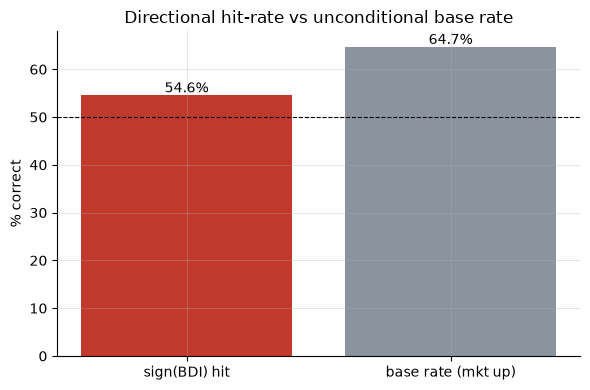

BDI-conditioned direction is right 54.6% of months vs base rate 64.7% -- it makes you WORSE.


In [7]:
if HAVE_REAL:
    h = st.sign_hit_rate(sig, fwd)
    hit, base = h["hit"], h["base_rate"]
else:
    hit, base = R["hit"], R["base_rate"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["sign(BDI) hit", "base rate (mkt up)"], [hit*100, base*100], color=[RED, GREY])
ax.axhline(50, color="black", ls="--", lw=0.8)
ax.set_ylabel("% correct"); ax.set_title("Directional hit-rate vs unconditional base rate")
for i, v in enumerate([hit*100, base*100]):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.show()
print(f"BDI-conditioned direction is right {hit*100:.1f}% of months vs base rate {base*100:.1f}% -- it makes you WORSE.")


## Verdict

In [8]:
print("=== Study 269 -- Baltic-Dry ===")
print()
print(f"Signal: WEAK")
print(f"  Full-sample regression HAC t = +{R['reg_t']:.2f} (clears t>=2 naively)")
print(f"  BUT ex-2008/09 t = +{R['reg_ex2008_t']:.2f} (below bar); slope NEGATIVE in 1985-1999;")
print(f"  sign hit-rate {R['hit']*100:.1f}% < base rate {R['base_rate']*100:.1f}%. Not robust -> WEAK, not REAL.")
print()
print(f"Tradability: MIRAGE")
print(f"  Long-when-BDI-rising overlay LOSES {abs(R['exc_ann']):.1f}%/yr to buy-and-hold (t={R['exc_t']:.2f}),")
print(f"  lower Sharpe ({R['tim_sr']:.2f} vs {R['bh_sr']:.2f}); only a marginally shallower drawdown. No edge.")
print()
print(f"Curated-series bias: NAMED -- BDI is a hindsight-curated monthly reconstruction;")
print(f"  in-sample fit is flattered. Real numbers are indicative upper bounds.")
print()
print("Bottom line: Weak/Mirage -- the BDI co-moves with the macro cycle (esp. in 2008)")
print("  but does not reliably LEAD equities, and the tradable read destroys value.")


=== Study 269 -- Baltic-Dry ===

Signal: WEAK
  Full-sample regression HAC t = +2.82 (clears t>=2 naively)
  BUT ex-2008/09 t = +1.35 (below bar); slope NEGATIVE in 1985-1999;
  sign hit-rate 54.6% < base rate 64.7%. Not robust -> WEAK, not REAL.

Tradability: MIRAGE
  Long-when-BDI-rising overlay LOSES 3.3%/yr to buy-and-hold (t=-1.90),
  lower Sharpe (0.76 vs 0.80); only a marginally shallower drawdown. No edge.

Curated-series bias: NAMED -- BDI is a hindsight-curated monthly reconstruction;
  in-sample fit is flattered. Real numbers are indicative upper bounds.

Bottom line: Weak/Mirage -- the BDI co-moves with the macro cycle (esp. in 2008)
  but does not reliably LEAD equities, and the tradable read destroys value.
